### Check to make sure GPU is available

In [3]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

2025-10-25 14:10:16.271762: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-25 14:10:16.360884: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761415816.388217     988 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761415816.399601     988 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-25 14:10:16.509947: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 8956988025657715980
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 5833228288
locality {
  bus_id: 1
  links {
  }
}
incarnation: 12025925671614797540
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9"
xla_global_id: 416903419
]


I0000 00:00:1761415821.193121     988 gpu_device.cc:2022] Created device /device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


### Import necessary libraries

In [76]:
import pandas as pd
import numpy as np
import ruptures as rpt
import matplotlib.pyplot as plt

## All data (big and small circles together)

### Read in and visualize raw dataframe

In [122]:
raw_df = pd.read_csv("/home/abbie/projects/TECH646-Haptic-Results/data/raw_data_split.csv")

raw_df.set_index('subject_trial', inplace=True)

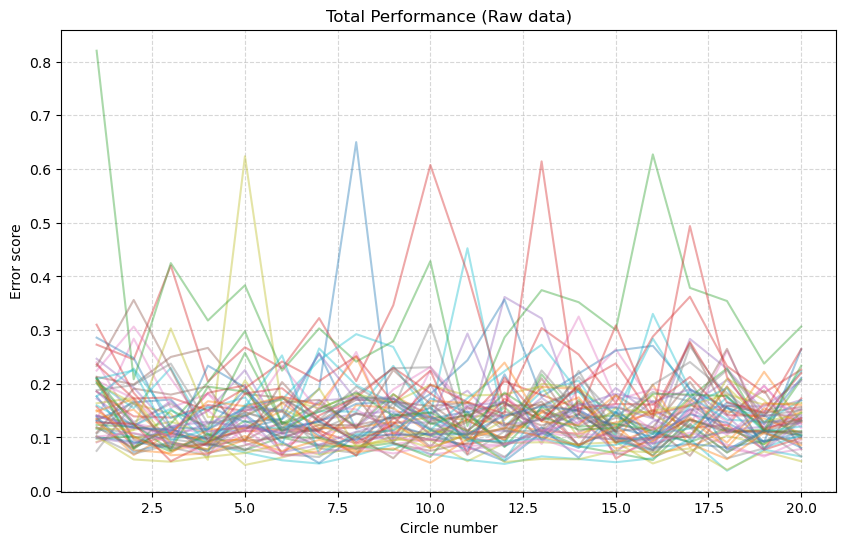

In [123]:
plt.figure(figsize=(10, 6))
for i, row in raw_df.iterrows():
    plt.plot(range(1, 21), row.values, alpha=0.4)  # faint line for each subject

plt.title("Total Performance (Raw data)")
plt.xlabel("Circle number")
plt.ylabel("Error score")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Clean up data by removing outliers and visualize

In [124]:
z_scores = (raw_df - raw_df.mean()) / raw_df.std()

# Replace values with NaN if they’re more than 2 standard deviations from the mean
df_clean = raw_df.mask(np.abs(z_scores) > 1.5)

# fill NaN with the median of that column instead of dropping
df_clean = df_clean.apply(lambda x: x.fillna(x.median()), axis=0)

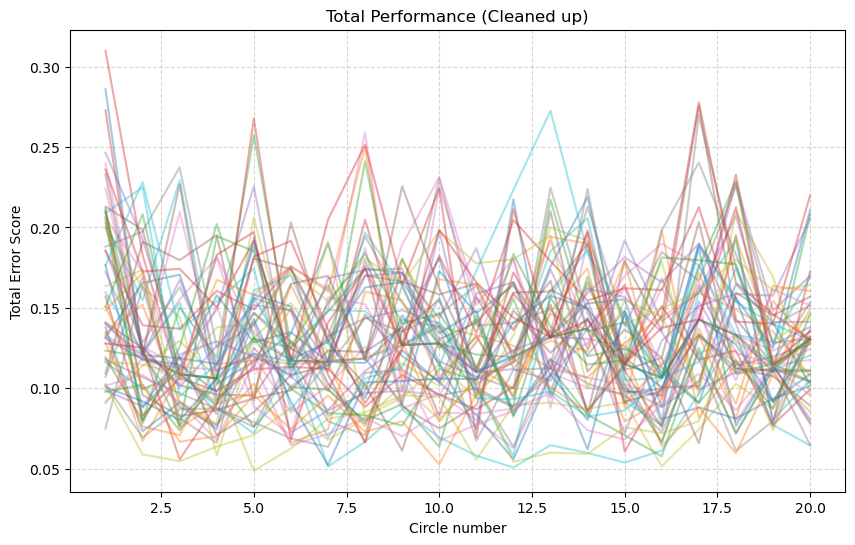

In [125]:
plt.figure(figsize=(10, 6))
for i, row in df_clean.iterrows():
    plt.plot(range(1, 21), row.values, alpha=0.4)  # faint line for each subject

plt.title("Total Performance (Cleaned up)")
plt.xlabel("Circle number")
plt.ylabel("Total Error Score")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Make function to calculate change

In [169]:
def get_change(start, end):
    difference = end - start
    change = difference / start
    percent_change = change * 100
    return percent_change

### Calculate the percentage change for various window sizes in the data

In [170]:
window_sizes = [4, 8, 12, 16, 20]
#window_sizes = [4]
percent_dict = {}

for window in window_sizes:
    all_percents = []
    for i, row in df_clean.iterrows():
        errors = row.values
        for start in range(len(errors) - window + 1):
            start_val = errors[start]

            end_val = errors[start + window - 1]

            all_percents.append(get_change(start_val, end_val))

    percent_dict[window] = np.array(all_percents)


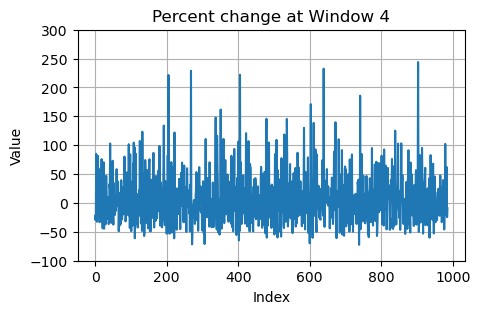

Number of percent samples: 986


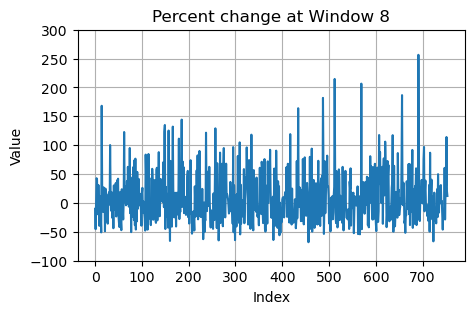

Number of percent samples: 754


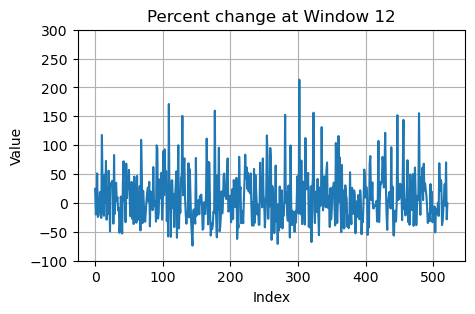

Number of percent samples: 522


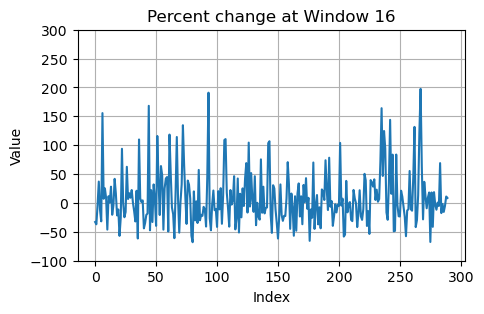

Number of percent samples: 290


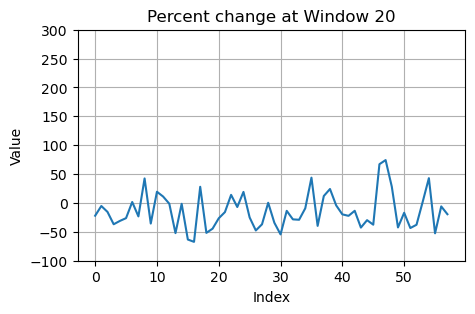

Number of percent samples: 58


In [171]:
for window, percent in percent_dict.items():
    plt.figure(figsize=(5, 3))
    plt.plot(range(len(percent)), percent)
    plt.title(f'Percent change at Window {window}')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.ylim(-100, 300)
    plt.grid(True)
    plt.show()
    print("Number of percent samples:", len(percent))

### Ruptures to detect change

In [1]:
for subj in range(len(df_clean)): # iterature through every subject
    signal = small_clean.iloc[subj].values  # given subject’s 40 error values

    # Choose model and penalty (tune this)
    model = "rbf"   # for nonlinear patterns
    algo = rpt.Pelt(model=model, jump=1).fit(signal)

    # Change the penalty value to control sensitivity
    change_points = algo.predict(pen=1)

    true_change_points = change_points[:-1] # take off 40 from the end

    print(f"Subject {subj+1} change points:", true_change_points)

    # Plot
    rpt.display(signal, change_points, figsize=(10, 4))
    plt.title(f"Subject {subj+1} Error Change Points")
    plt.xlabel("Circle Number")
    plt.ylabel("Error")
    plt.show()

NameError: name 'df_clean' is not defined

Total change points: [8, 30]


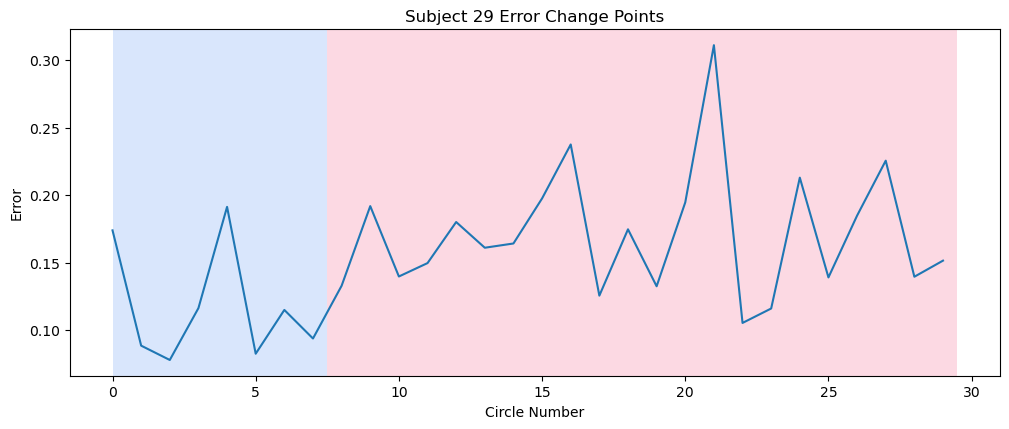

In [ ]:
print(f"Total change points:", change_points)

algo_total = rpt.Window(model='l2').fit(df_clean.values)
result_total = algo_total.predict(pen=20)

# Plot
rpt.display(signal, change_points, figsize=(10, 4))
plt.title(f"Subject {subj+1} Error Change Points")
plt.xlabel("Circle Number")
plt.ylabel("Error")
plt.show()


### Gaussian Mixture to determine slope thresholds

In [ ]:
# from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
# from scipy.stats import norm

# def find_intersection(mu1, sigma1, mu2, sigma2):
#     # Numerical intersection of two 1D Gaussians
#     x = np.linspace(min(mu1, mu2) - 3*max(sigma1, sigma2),
#                     max(mu1, mu2) + 3*max(sigma1, sigma2), 10000)
#     p1 = norm.pdf(x, mu1, sigma1)
#     p2 = norm.pdf(x, mu2, sigma2)
#     idx = np.argwhere(np.diff(np.sign(p1 - p2))).flatten()
#     return x[idx]

# thresholds = {}
# gmm_results = {}

# for window, slopes in slopes_dict.items():
#     slopes_reshaped = slopes.reshape(-1, 1)
#     gmm = GaussianMixture(n_components=3, n_init=100, covariance_type='full', tol=.1)
#     gmm.fit(slopes_reshaped)
    
#     means = np.sort(gmm.means_.flatten())
#     sigmas = np.sqrt(np.sort(gmm.covariances_.flatten()))
    
#     t1 = find_intersection(means[0], sigmas[0], means[1], sigmas[1])[0]
#     t2 = find_intersection(means[1], sigmas[1], means[2], sigmas[2])[0]
    
#     thresholds[window] = {"learning_nothing": t1, "nothing_fatigue": t2}
#     gmm_results[window] = {"means": means, "sigmas": sigmas, "slopes": slopes}

# # Display thresholds per window
# for w, t in thresholds.items():
#     print(f"Window {w}: Learning–Nothing = {t['learning_nothing']:.4f}, Nothing–Fatigue = {t['nothing_fatigue']:.4f}")


Window 8: Learning–Nothing = -0.0038, Nothing–Fatigue = 0.0038


### Gaussian Mixture take 2

#### Ensure the data is normal


Window 4:
  Shapiro-Wilk p = 2.8652e-22
  D'Agostino K² p = 6.9826e-59
Normality is statistically significant at 99% confidence.


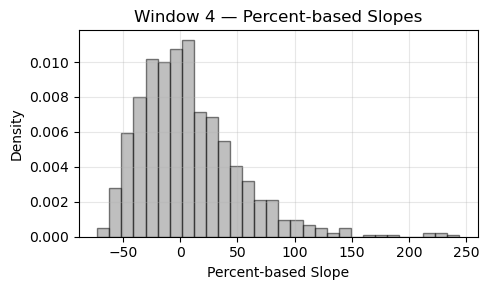


Window 8:
  Shapiro-Wilk p = 1.6074e-19
  D'Agostino K² p = 8.2946e-44
Normality is statistically significant at 99% confidence.


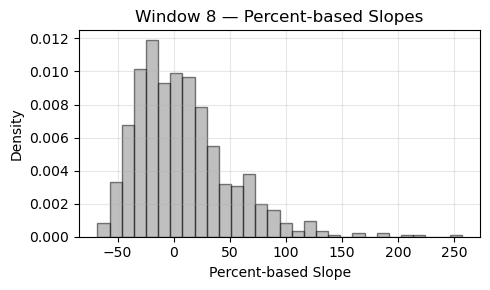


Window 12:
  Shapiro-Wilk p = 3.0597e-13
  D'Agostino K² p = 1.1049e-20
Normality is statistically significant at 99% confidence.


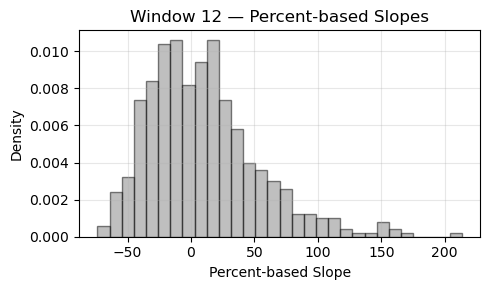


Window 16:
  Shapiro-Wilk p = 7.1903e-12
  D'Agostino K² p = 1.4974e-15
Normality is statistically significant at 99% confidence.


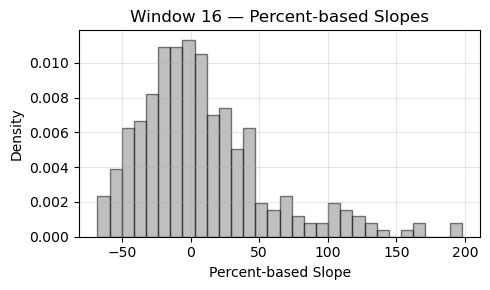


Window 20:
  Shapiro-Wilk p = 2.7494e-02
  D'Agostino K² p = 3.6113e-02
Normality is NOT statistically significant at 99% confidence.


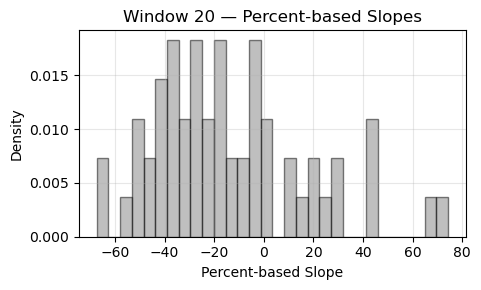

In [172]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, normaltest
from colorama import Fore

for window, data in percent_dict.items():
    data = data[~np.isnan(data)]  # drop NaNs if any

    # run simple normality tests
    shapiro_stat, shapiro_p = shapiro(data[:5000])  # Shapiro max n=5000
    dagostino_stat, dagostino_p = normaltest(data)

    print(f"\nWindow {window}:")
    print(f"  Shapiro-Wilk p = {shapiro_p:.4e}")
    print(f"  D'Agostino K² p = {dagostino_p:.4e}")

    if (shapiro_p < 0.01 and dagostino_p < 0.01):
        print(Fore.GREEN + f"Normality is statistically significant at 99% confidence.") #figure out if two tailed or what
    else:
        print(Fore.RED + f"Normality is NOT statistically significant at 99% confidence.")

    # visualize histogram
    plt.figure(figsize=(5,3))
    plt.hist(data, bins=30, density=True, alpha=0.5, color='gray', edgecolor='black')
    plt.title(f"Window {window} — Percent-based Slopes")
    plt.xlabel("Percent-based Slope")
    plt.ylabel("Density")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


### Find intersections

In [132]:
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
import numpy as np
from scipy.stats import norm

def find_intersection(mu1, sigma1, mu2, sigma2):
    # Numerical intersection of two 1D Gaussians
    x = np.linspace(min(mu1, mu2) - 3*max(sigma1, sigma2),
                    max(mu1, mu2) + 3*max(sigma1, sigma2), 10000)
    p1 = norm.pdf(x, mu1, sigma1)
    p2 = norm.pdf(x, mu2, sigma2)
    idx = np.argwhere(np.diff(np.sign(p1 - p2))).flatten()
    return x[idx]

thresholds = {}
gmm_results = {}

for window, percent in percent_dict.items():
    percents_reshaped = percent.reshape(-1, 1)
    
    # Fit GMM
    gmm = GaussianMixture(n_components=3, n_init=100, tol=0.001)
    gmm.fit(percents_reshaped)
    
    # Get sorted means and stds
    means = np.sort(gmm.means_.flatten())
    sigmas = np.sqrt(np.sort(gmm.covariances_.flatten()))
    
    # Use component means as thresholds
    t1 = means[0]  # "learning_nothing"
    t2 = means[2]  # "nothing_fatigue"

    # t1 = find_intersection(means[0], sigmas[0], means[1], sigmas[1])[0]
    # t2 = find_intersection(means[1], sigmas[1], means[2], sigmas[2])[0]
    
    thresholds[window] = {
        "learning_nothing": t1,
        "nothing_fatigue": t2,
    }
    
    gmm_results[window] = {"means": means, "sigmas": sigmas, "percents": percent}

# Display thresholds per window
for w, t in thresholds.items():
    print(f"Window {w}: Learning–Nothing = {t['learning_nothing']:.4f}, Nothing–Fatigue = {t['nothing_fatigue']:.4f}")


Window 4: Learning–Nothing = -21.8226, Nothing–Fatigue = 76.0606
Window 8: Learning–Nothing = -25.0449, Nothing–Fatigue = 63.7856
Window 12: Learning–Nothing = -24.5767, Nothing–Fatigue = 77.6267
Window 16: Learning–Nothing = -25.1705, Nothing–Fatigue = 98.2505
Window 20: Learning–Nothing = -33.3720, Nothing–Fatigue = 49.8540


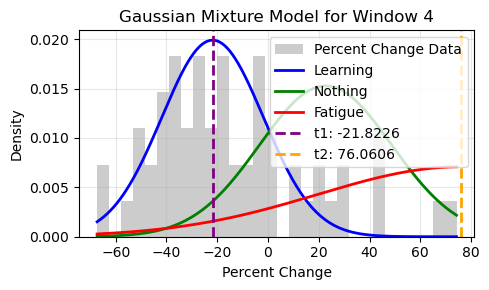

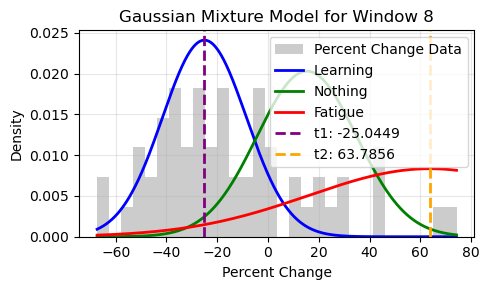

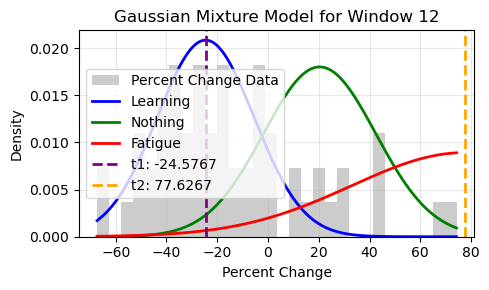

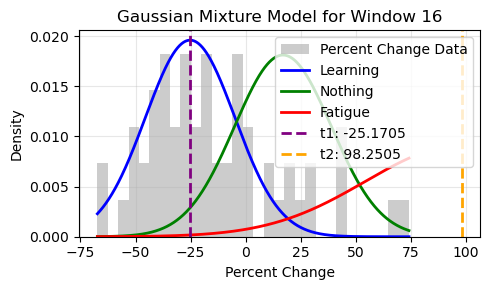

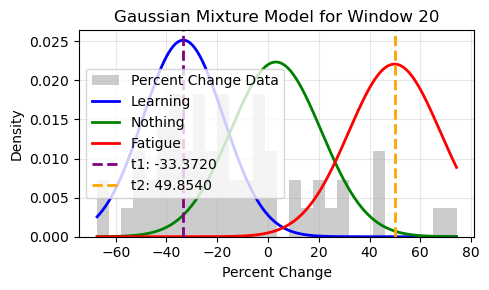

In [133]:
# --- Now plot for windows using the already computed results ---
for window in window_sizes: 
    window_to_plot = window
    res = gmm_results[window_to_plot]
    means = res["means"]
    sigmas = res["sigmas"]
    percents = res["percents"]

    x = np.linspace(percent.min(), percent.max(), 1000)
    pdfs = [norm.pdf(x, mu, sigma) for mu, sigma in zip(means, sigmas)]
    t1 = thresholds[window_to_plot]["learning_nothing"]
    t2 = thresholds[window_to_plot]["nothing_fatigue"]

    plt.figure(figsize=(5,3))
    plt.hist(percent, bins=30, density=True, alpha=0.4, color='gray', label='Percent Change Data')
    colors = ['blue', 'green', 'red']
    labels = ['Learning', 'Nothing', 'Fatigue']
    for pdf, color, label in zip(pdfs, colors, labels):
        plt.plot(x, pdf, color=color, lw=2, label=label)
    plt.axvline(t1, color='purple', linestyle='--', lw=2, label=f't1: {t1:.4f}')
    plt.axvline(t2, color='orange', linestyle='--', lw=2, label=f't2: {t2:.4f}')
    plt.title(f"Gaussian Mixture Model for Window {window_to_plot}")
    plt.xlabel("Percent Change")
    plt.ylabel("Density")
    # plt.xlim(-0.05, 0.05)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### Find 90% probability

In [184]:
from sklearn.mixture import GaussianMixture,BayesianGaussianMixture
from scipy.stats import norm
import numpy as np

desired_probability = 0.9
conf_percent = str(desired_probability * 100) + "%"
thresholds = {}
gmm_results = {}

for window, percent in percent_dict.items():
    percents_reshaped = percent.reshape(-1, 1) # reshape the percents
    gmm = GaussianMixture(n_components=3, n_init=100, tol=0.001) # create GMM
    gmm.fit(percents_reshaped) # fit the GMM to the data
    
    # Sort components
    means = gmm.means_.flatten()
    #print(f"GMM mean at window {window}: {means}")
    sigmas = np.sqrt(gmm.covariances_.flatten())
    #print(f"GMM sigma at window {window}: {sigmas}")
    order = np.argsort(means)
    means, sigmas, weights = means[order], sigmas[order], gmm.weights_[order]
    
    # Compute posteriors over value range
    x = np.linspace(np.min(percent), np.max(percent), 10000)
    # probability distribution function
    pdfs = np.array([w * norm.pdf(x, m, s) for w, m, s in zip(weights, means, sigmas)])
    posteriors = pdfs / np.sum(pdfs, axis=0)
    
    # confidence thresholds
    # learning gruop is index 0
    learning_cutoff = x[np.where(posteriors[0] >= desired_probability)[0][-1]] if np.any(posteriors[0] >= desired_probability) else np.nan
    # fatigue group is index 2
    fatigue_cutoff = x[np.where(posteriors[2] >= desired_probability)[0][0]] if np.any(posteriors[2] >= desired_probability) else np.nan

    thresholds[window] = {
        "learning_cutoff": learning_cutoff,
        "fatigue_cutoff": fatigue_cutoff,
        "means": means,
    }
    gmm_results[window] = {"means": means, "sigmas": sigmas, "weights": weights}

# Display thresholds
for w, t in thresholds.items():
    print(f"Window {w}:")
    print(f"  {conf_percent} Learning cutoff: {t['learning_cutoff']:.4f}")
    print(f"  {conf_percent} Fatigue cutoff: {t['fatigue_cutoff']:.4f}")


Window 4:
  90.0% Learning cutoff: -28.7649
  90.0% Fatigue cutoff: 99.0422
Window 8:
  90.0% Learning cutoff: -25.7620
  90.0% Fatigue cutoff: 68.4493
Window 12:
  90.0% Learning cutoff: -24.6059
  90.0% Fatigue cutoff: 83.4577
Window 16:
  90.0% Learning cutoff: -27.4869
  90.0% Fatigue cutoff: 80.1048
Window 20:
  90.0% Learning cutoff: -28.3988
  90.0% Fatigue cutoff: 50.2778


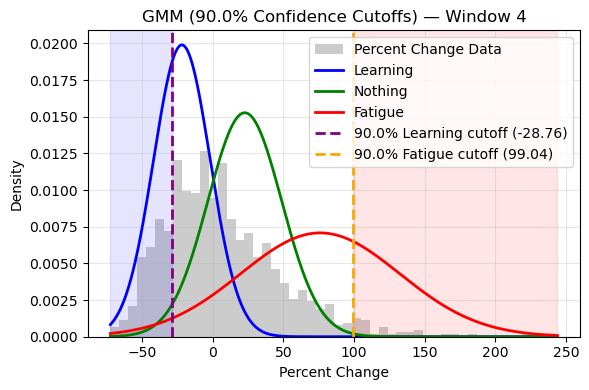

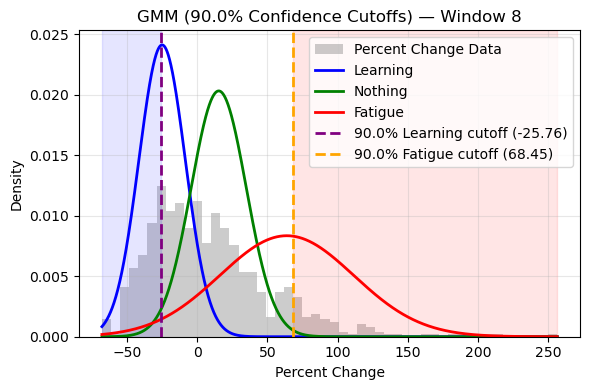

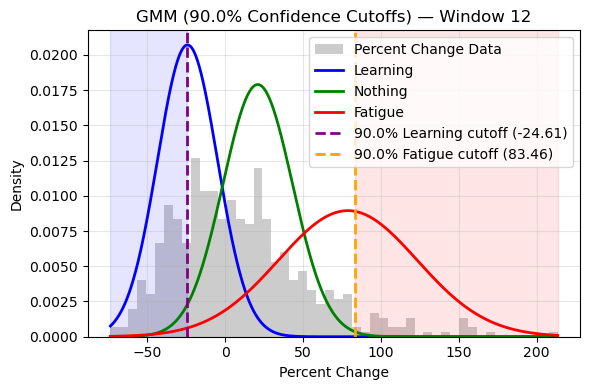

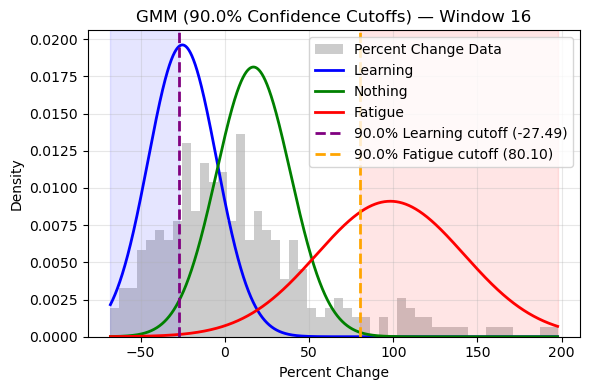

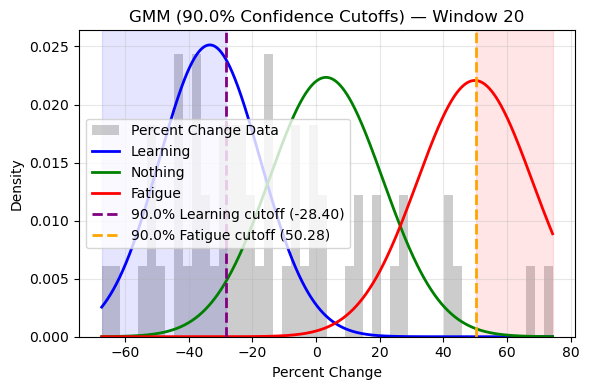

In [185]:
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np

for window in window_sizes: 
    results = gmm_results[window]
    means = results["means"]
    sigmas = results["sigmas"]
    percents = percent_dict[window]

    # Compute Gaussian PDFs
    x = np.linspace(np.nanmin(percents), np.nanmax(percents), 10000)
    pdfs = [norm.pdf(x, mu, sigma) for mu, sigma in zip(means, sigmas)]
    
    # Extract confidence cutoffs
    t_learning = thresholds[window]["learning_cutoff"]
    t_fatigue = thresholds[window]["fatigue_cutoff"]

    # Plot histogram
    plt.figure(figsize=(6, 4))
    plt.hist(percents, bins=50, density=True, alpha=0.4, color='gray', label='Percent Change Data')

    # Plot Gaussians
    colors = ['blue', 'green', 'red']
    labels = ['Learning', 'Nothing', 'Fatigue']
    for pdf, color, label in zip(pdfs, colors, labels):
        plt.plot(x, pdf, color=color, lw=2, label=label)

    # Optional: shaded regions for high-confidence areas
    if not np.isnan(t_learning):
        plt.axvspan(x.min(), t_learning, color='blue', alpha=0.1)
    if not np.isnan(t_fatigue):
        plt.axvspan(t_fatigue, x.max(), color='red', alpha=0.1)

    # Plot 90% confidence cutoffs
    if not np.isnan(t_learning):
        plt.axvline(t_learning, color='purple', linestyle='--', lw=2,
                    label=f'{conf_percent} Learning cutoff ({t_learning:.2f})')
    if not np.isnan(t_fatigue):
        plt.axvline(t_fatigue, color='orange', linestyle='--', lw=2,
                    label=f'{conf_percent} Fatigue cutoff ({t_fatigue:.2f})')

    
    plt.title(f"GMM ({conf_percent} Confidence Cutoffs) — Window {window}")
    plt.xlabel("Percent Change")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


### Figure out if slopes calculated are statistically significant
#### H0 = The slope at or beyond the calculated threshold is due to random variation
#### H1 = The slope at or beyond the calculated threshold is due to learning or fatigue

In [186]:
from scipy import stats
import statistics
from colorama import Fore

for w, t in thresholds.items():
    print(Fore.CYAN + f"Window {w}: mean percent change is {statistics.mean(percent_dict[w])}")
    t_stat, p_value = stats.ttest_1samp(percent_dict[w], t['learning_cutoff'])
    if (p_value < 0.001):
        print(Fore.GREEN + f"Learning threshold = {t['learning_cutoff']:.4f} is statistically significant with a p-value of {p_value}") 
    else:
        print(Fore.RED + f"Learning threshold = {t['learning_cutoff']:.4f} is NOT statistically significant with a p-value of {p_value}")
    t_stat, p_value = stats.ttest_1samp(percent_dict[w], t['fatigue_cutoff'])
    if (p_value < 0.001):
        print(Fore.GREEN + f"Fatigue threshold = {t['fatigue_cutoff']:.4f} is statistically significant with a p-value of {p_value}")
    else:
        print(Fore.RED + f"Fatigue threshold = {t['fatigue_cutoff']:.4f} is NOT statistically significant with a p-value of {p_value}")

Window 4: mean percent change is 7.225853140209378
Learning threshold = -28.7649 is statistically significant with a p-value of 1.7844899325363324e-113
Fatigue threshold = 99.0422 is statistically significant with a p-value of 0.0
Window 8: mean percent change is 8.229538385528642
Learning threshold = -25.7620 is statistically significant with a p-value of 5.806151704307246e-81
Fatigue threshold = 68.4493 is statistically significant with a p-value of 7.050629642948004e-179
Window 12: mean percent change is 9.238709957134779
Learning threshold = -24.6059 is statistically significant with a p-value of 3.435871943637228e-55
Fatigue threshold = 83.4577 is statistically significant with a p-value of 9.336736026942418e-156
Window 16: mean percent change is 8.476457920306942
Learning threshold = -27.4869 is statistically significant with a p-value of 2.53976695812447e-30
Fatigue threshold = 80.1048 is statistically significant with a p-value of 1.713045044974367e-76
Window 20: mean percent c

In [188]:
window = 4  # size of sliding window
learning_threshold = thresholds[window]["learning_cutoff"]  # slope threshold to classify changes - want to make this dynamic
print(f"Learning threshold: {learning_threshold}")

fatigue_threshold = thresholds[window]["fatigue_cutoff"]
print(f"Fatigue threshold: {fatigue_threshold}")

modes_list = []

for i, row in df_clean.iterrows():
    subject_modes = []
    errors = row.values
    for start in range(len(errors) - window + 1):
        window_vals = errors[start:start+window]
        x = np.arange(window)
        # Linear regression: slope = change per trial
        start_val = errors[start]

        end_val = errors[start + window - 1]

        percent_changed = get_change(start_val, end_val)

        if percent_changed < learning_threshold:
            subject_modes.append("learning")
        elif percent_changed > fatigue_threshold:
            subject_modes.append("fatigued")
        else:
            subject_modes.append("nothing")
    
    # Pad the beginning so the mode array is same length as trials
    subject_modes = ["nothing"]*(window-1) + subject_modes
    modes_list.append(subject_modes)

# Convert to DataFrame for easy handling
modes_df = pd.DataFrame(modes_list, index=df_clean.index, columns=df_clean.columns)

Learning threshold: -28.76490171082314
Fatigue threshold: 99.04219747933769


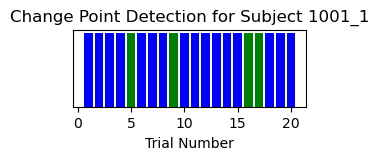

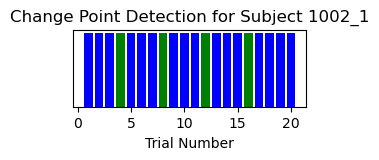

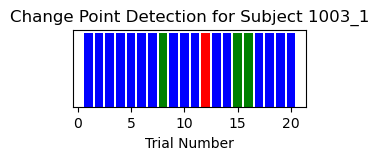

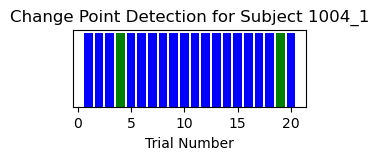

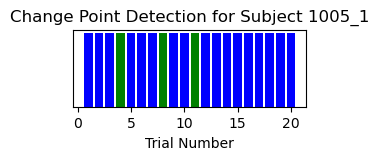

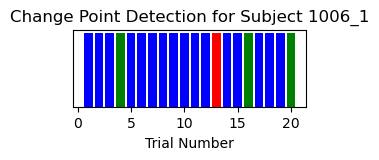

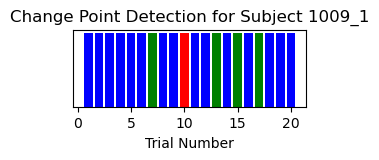

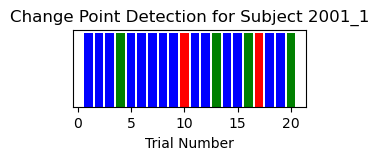

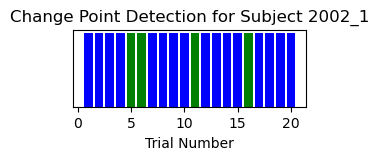

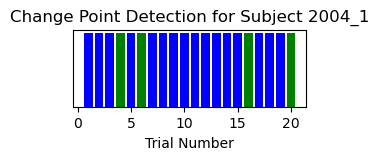

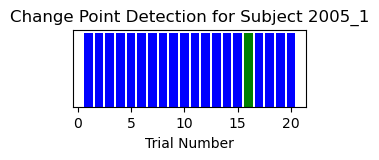

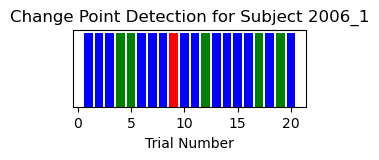

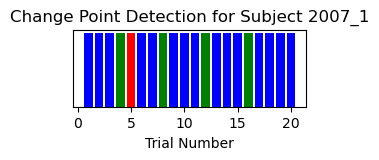

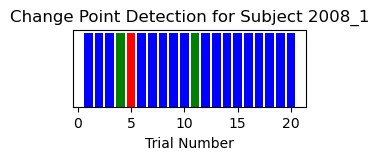

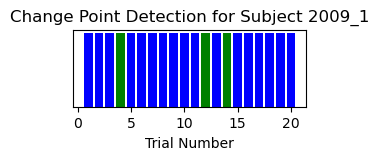

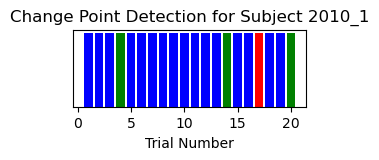

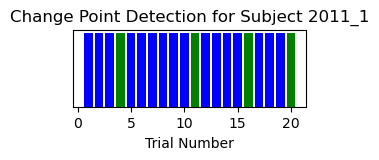

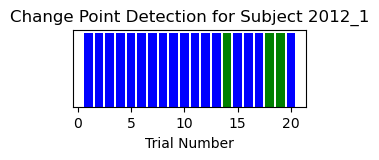

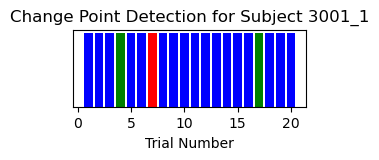

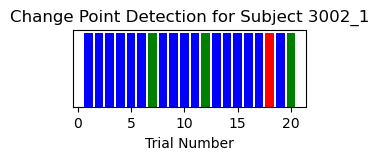

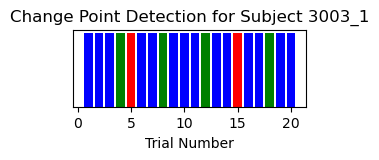

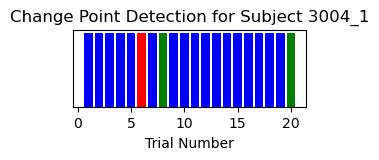

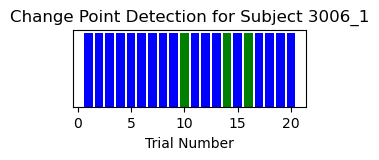

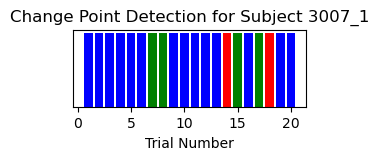

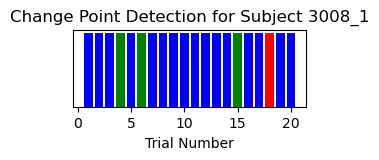

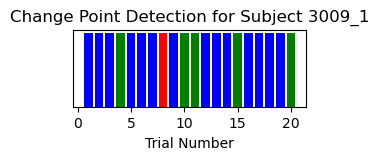

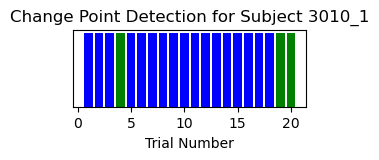

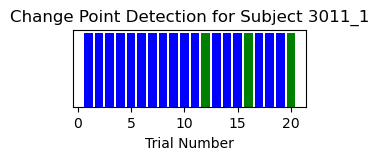

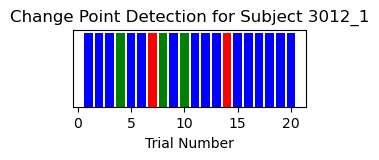

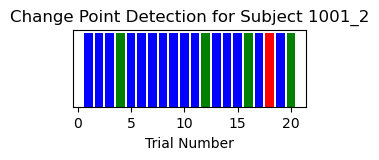

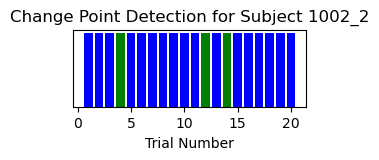

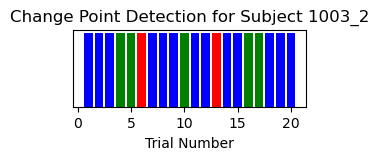

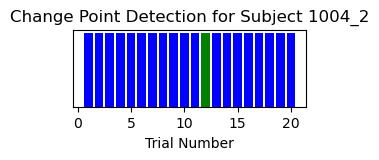

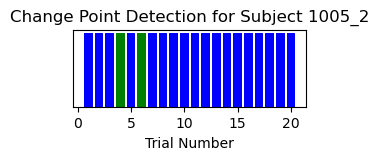

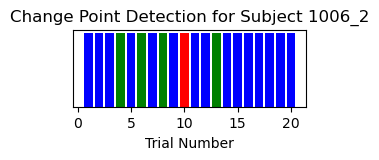

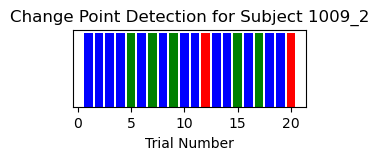

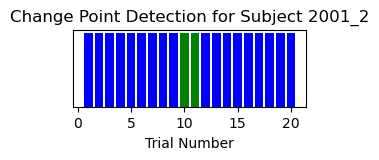

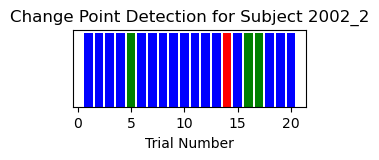

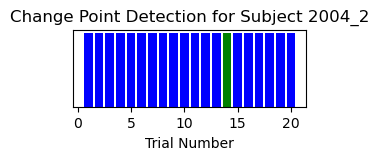

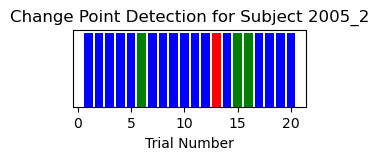

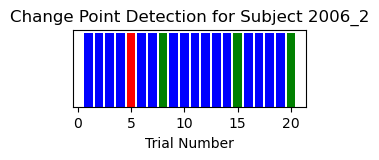

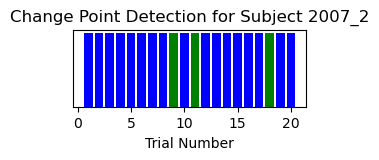

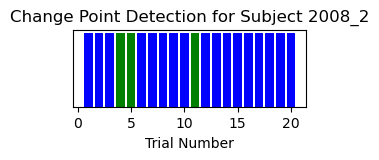

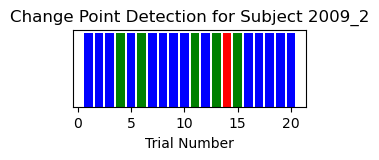

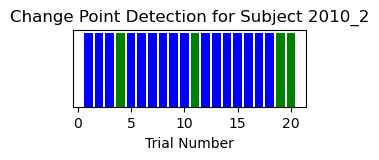

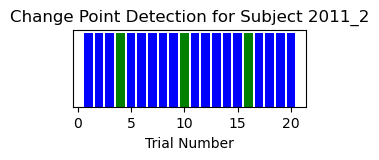

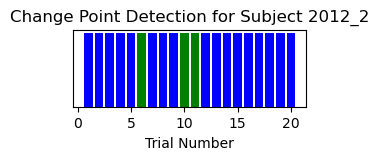

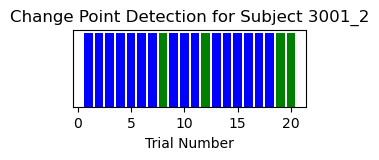

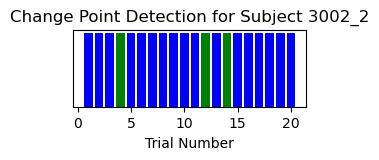

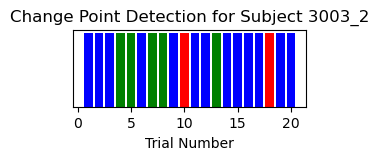

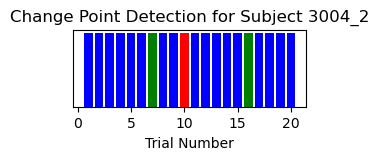

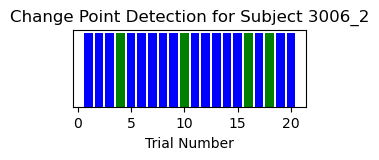

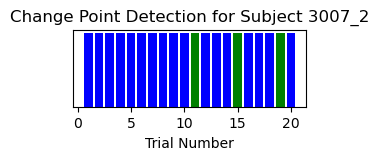

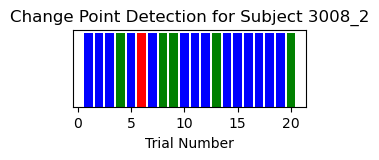

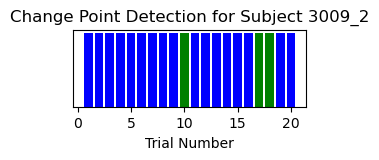

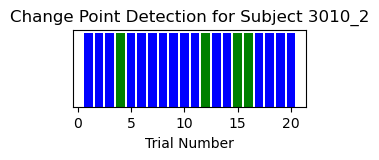

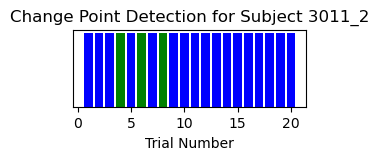

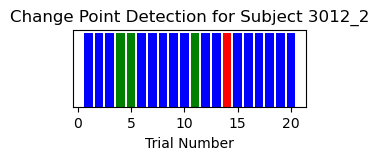

In [189]:
for i in range(0,58):
    subject = i
    colors = {"learning": "green", "nothing": "blue", "fatigued": "red"}
    # colors = {"learning": "green", "nothing": "blue"}
    modes = modes_df.iloc[subject]

    plt.figure(figsize=(3,1))
    for i, mode in enumerate(modes):
        plt.bar(i+1, 1, color=colors[mode])

    plt.title(f"Change Point Detection for Subject {df_clean.index[subject]}")
    plt.xlabel("Trial Number")
    plt.yticks([])
    plt.show()

## Clean up just for small circle data

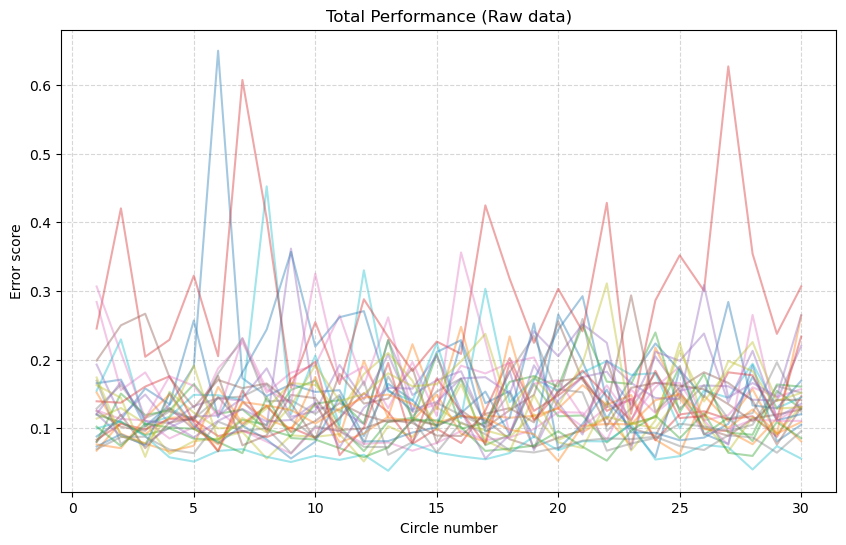

In [422]:
small_df = raw_df.drop(raw_df.filter(like='big', axis=1), axis=1)

plt.figure(figsize=(10, 6))
for i, row in small_df.iterrows():
    plt.plot(range(1, 31), row.values, alpha=0.4)  # faint line for each subject

plt.title("Total Performance (Raw data)")
plt.xlabel("Circle number")
plt.ylabel("Error score")
plt.grid(True, linestyle="--", alpha=0.5)

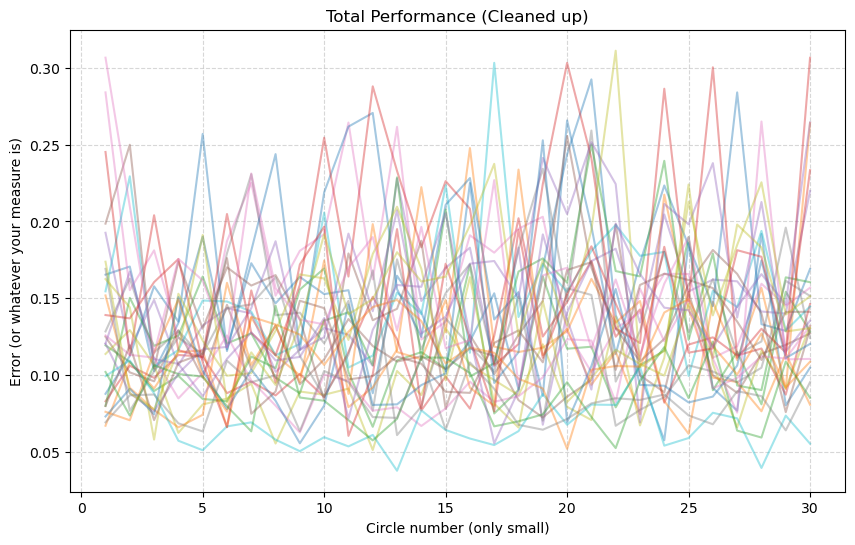

In [423]:
# Replace values with NaN if they’re more than 2.5 standard deviations from the mean
small_clean = small_df.mask(np.abs(z_scores) > 2.8)

# fill NaN with the median of that column instead of dropping
small_clean = small_clean.apply(lambda x: x.fillna(x.median()), axis=0)

plt.figure(figsize=(10, 6))
for i, row in small_clean.iterrows():
    plt.plot(range(1, 31), row.values, alpha=0.4)  # faint line for each subject

plt.title("Total Performance (Cleaned up)")
plt.xlabel("Circle number (only small)")
plt.ylabel("Error (or whatever your measure is)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [424]:
# window_sizes = [4, 8, 16, 20, 40] # each window contains the same number of big and small circles
window_sizes = [5, 10, 20] # each window contains the same number of big and small circles

slopes_dict = {}  # to store slopes for each window

for window in window_sizes:
    all_slopes = []
    for i, row in small_clean.iterrows():
        errors = row.values
        for start in range(len(errors) - window + 1):
            window_vals = errors[start:start+window]
            x = np.arange(window)
            
            # Skip flat windows (all values identical)
            if np.all(window_vals == window_vals[0]):
                slope = 0.0
            else:
                slope = np.polyfit(x, window_vals, 1)[0]
            
            all_slopes.append(slope)
    
    slopes_dict[window] = np.array(all_slopes)

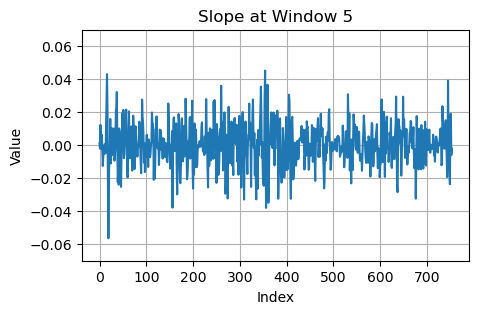

Number of slope samples: 754


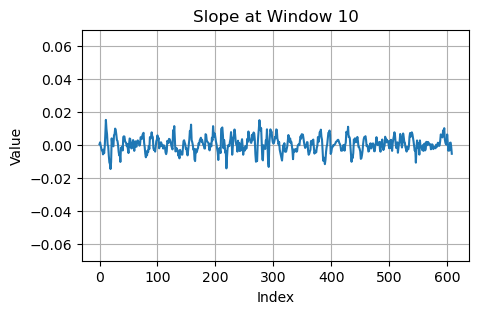

Number of slope samples: 609


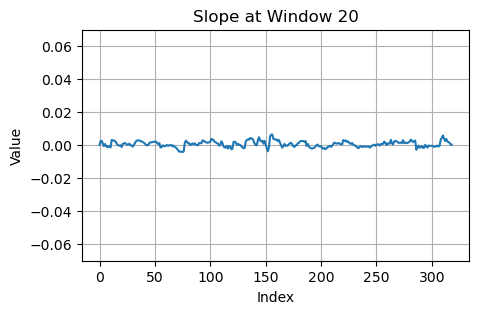

Number of slope samples: 319


In [425]:
for window, slope in slopes_dict.items():
    plt.figure(figsize=(5, 3))
    plt.plot(range(len(slope)), slope)
    plt.title(f'Slope at Window {window}')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.ylim(-0.07, 0.07)
    plt.grid(True)
    plt.show()
    print("Number of slope samples:", len(slope))

In [434]:
from sklearn.mixture import GaussianMixture
import numpy as np

thresholds = {}
gmm_results = {}

for window, slopes in slopes_dict.items():
    slopes_reshaped = slopes.reshape(-1, 1)
    
    # Fit GMM
    gmm = GaussianMixture(n_components=3, n_init=100, covariance_type='full', tol=.0001)
    gmm.fit(slopes_reshaped)
    
    # Get sorted means and stds
    means = np.sort(gmm.means_.flatten())
    sigmas = np.sqrt(np.sort(gmm.covariances_.flatten()))
    
    # Use component means as thresholds
    t1 = means[0]  # "learning_nothing"
    t2 = means[2]  # "nothing_fatigue"
    
    thresholds[window] = {
        "learning_nothing": t1,
        "nothing_fatigue": t2,
    }
    
    gmm_results[window] = {"means": means, "sigmas": sigmas, "slopes": slopes}

# Display thresholds per window
for w, t in thresholds.items():
    print(f"Window {w}: Learning–Nothing = {t['learning_nothing']:.4f}, Nothing–Fatigue = {t['nothing_fatigue']:.4f}")


Window 5: Learning–Nothing = -0.0118, Nothing–Fatigue = 0.0108
Window 10: Learning–Nothing = -0.0042, Nothing–Fatigue = 0.0054
Window 20: Learning–Nothing = 0.0006, Nothing–Fatigue = 0.0009


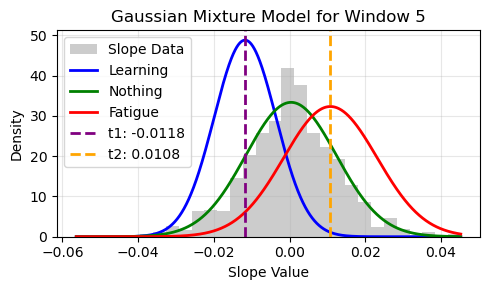

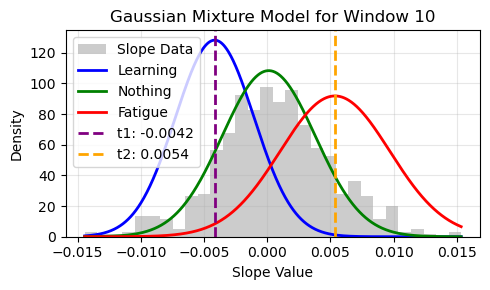

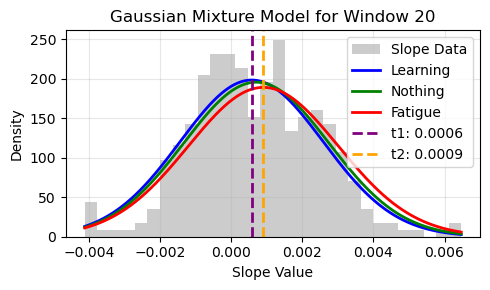

In [435]:
# --- Now plot for windows using the already computed results ---
for window in window_sizes: 
    window_to_plot = window
    res = gmm_results[window_to_plot]
    means = res["means"]
    sigmas = res["sigmas"]
    slopes = res["slopes"]

    x = np.linspace(slopes.min(), slopes.max(), 1000)
    pdfs = [norm.pdf(x, mu, sigma) for mu, sigma in zip(means, sigmas)]
    t1 = thresholds[window_to_plot]["learning_nothing"]
    t2 = thresholds[window_to_plot]["nothing_fatigue"]

    plt.figure(figsize=(5,3))
    plt.hist(slopes, bins=30, density=True, alpha=0.4, color='gray', label='Slope Data')
    colors = ['blue', 'green', 'red']
    labels = ['Learning', 'Nothing', 'Fatigue']
    for pdf, color, label in zip(pdfs, colors, labels):
        plt.plot(x, pdf, color=color, lw=2, label=label)
    plt.axvline(t1, color='purple', linestyle='--', lw=2, label=f't1: {t1:.4f}')
    plt.axvline(t2, color='orange', linestyle='--', lw=2, label=f't2: {t2:.4f}')
    plt.title(f"Gaussian Mixture Model for Window {window_to_plot}")
    plt.xlabel("Slope Value")
    plt.ylabel("Density")
    # plt.xlim(-0.05, 0.05)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [436]:
from scipy import stats
import statistics
from colorama import Fore

for w, t in thresholds.items():
    print(Fore.CYAN + f"Window {w}: mean slope is {statistics.mean(slopes_dict[w])}")
    t_stat, p_value = stats.ttest_1samp(slopes_dict[w], t['learning_nothing'])
    if (p_value < 0.001):
        print(Fore.GREEN + f"Learning–Nothing = {t['learning_nothing']:.4f} is statistically significant with a p-value of {p_value}") 
    else:
        print(Fore.RED + f"Learning–Nothing = {t['learning_nothing']:.4f} is NOT statistically significant with a p-value of {p_value}")
    t_stat, p_value = stats.ttest_1samp(slopes_dict[w], t['nothing_fatigue'])
    if (p_value < 0.001):
        print(Fore.GREEN + f"Nothing–Fatigue = {t['nothing_fatigue']:.4f} is statistically significant with a p-value of {p_value}")
    else:
        print(Fore.RED + f"Nothing–Fatigue = {t['nothing_fatigue']:.4f} is NOT statistically significant with a p-value of {p_value}")

Window 5: mean slope is 0.00035646655490715
Learning–Nothing = -0.0118 is statistically significant with a p-value of 4.117076960574136e-109
Nothing–Fatigue = 0.0108 is statistically significant with a p-value of 3.1477178774205108e-87
Window 10: mean slope is 0.0005458213423097991
Learning–Nothing = -0.0042 is statistically significant with a p-value of 1.2574668347048306e-97
Nothing–Fatigue = 0.0054 is statistically significant with a p-value of 3.683370720535835e-101
Window 20: mean slope is 0.0007014434951646332
Learning–Nothing = 0.0006 is NOT statistically significant with a p-value of 0.2151611031116186
Nothing–Fatigue = 0.0009 is NOT statistically significant with a p-value of 0.04243593261229173


In [437]:
window = 5  # size of sliding window
learning_threshold = thresholds[window]["learning_nothing"]  # slope threshold to classify changes - want to make this dynamic
print(f"Learning threshold: {learning_threshold}")

fatigue_threshold = thresholds[window]["nothing_fatigue"]
print(f"Fatigue threshold: {fatigue_threshold}")

modes_list = []

for i, row in small_clean.iterrows():
    subject_modes = []
    errors = row.values
    for start in range(len(errors) - window + 1):
        window_vals = errors[start:start+window]
        x = np.arange(window)
        # Linear regression: slope = change per trial
        slope = np.polyfit(x, window_vals, 1)[0]
        
        if slope < learning_threshold:
            subject_modes.append("learning")
        elif slope > fatigue_threshold:
            subject_modes.append("fatigued")
        else:
            subject_modes.append("nothing")
    
    # Pad the beginning so the mode array is same length as trials
    subject_modes = ["nothing"]*(window-1) + subject_modes
    modes_list.append(subject_modes)

# Convert to DataFrame for easy handling
modes_df = pd.DataFrame(modes_list, index=small_clean.index, columns=small_clean.columns)

Learning threshold: -0.011768449206136644
Fatigue threshold: 0.010783747983350847


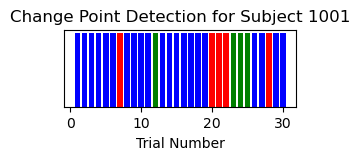

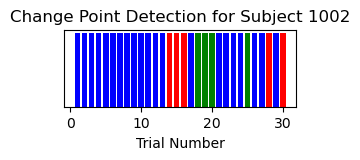

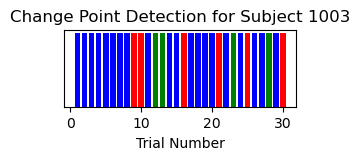

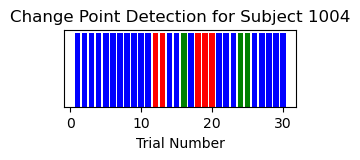

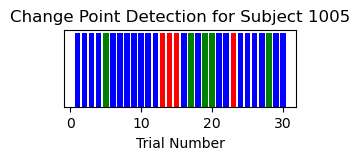

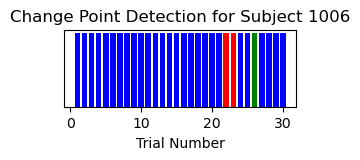

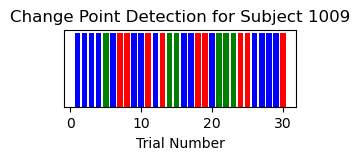

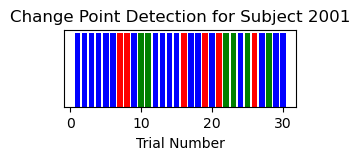

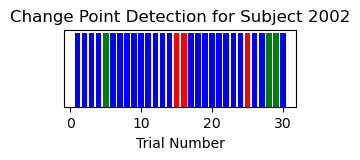

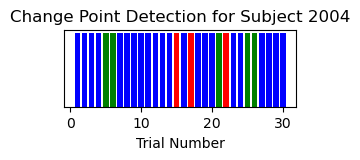

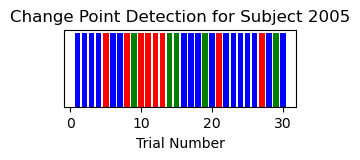

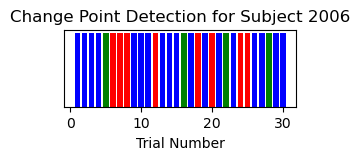

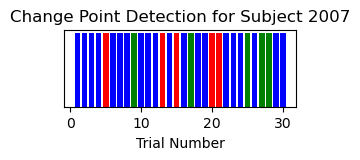

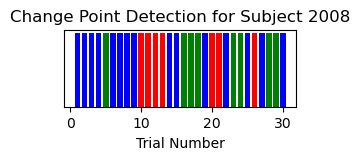

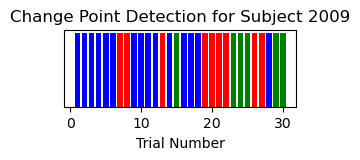

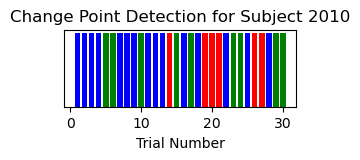

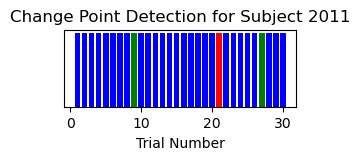

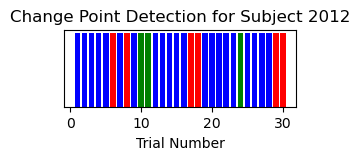

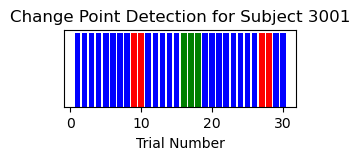

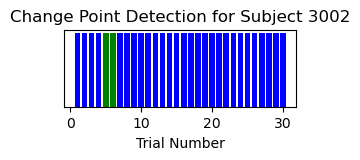

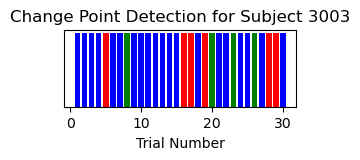

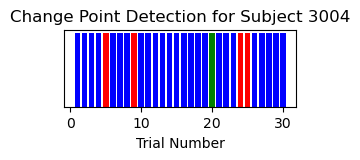

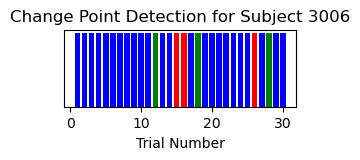

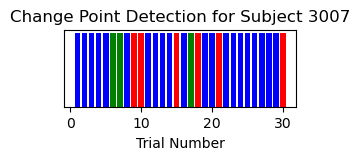

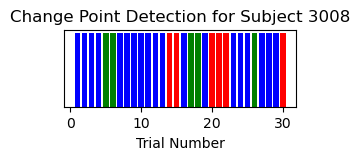

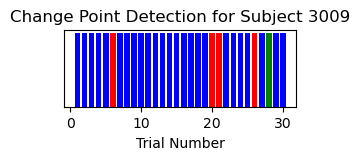

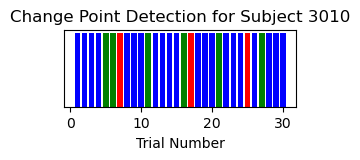

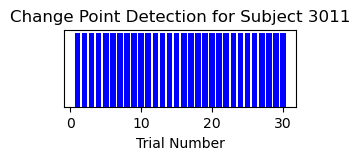

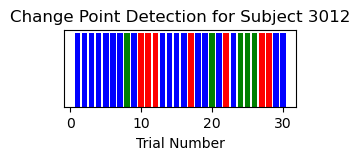

In [438]:
for i in range(0,29): # make dynamic for number of subjects
    subject = i
    colors = {"learning": "green", "nothing": "blue", "fatigued": "red"}
    # colors = {"learning": "green", "nothing": "blue"}
    modes = modes_df.iloc[subject]

    plt.figure(figsize=(3,1))
    for i, mode in enumerate(modes):
        plt.bar(i+1, 1, color=colors[mode])

    plt.title(f"Change Point Detection for Subject {small_clean.index[subject]}")
    plt.xlabel("Trial Number")
    plt.yticks([])
    plt.show()